In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
titanic_df=pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
titanic_df['Age']=titanic_df['Age'].fillna(titanic_df['Age'].median())
titanic_df['Embarked']=titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])


In [ ]:
features=['Pclass', 'Sex', 'Age', 'SibSp', 'Parch','Fare', 'Embarked']
target='Survived'

class_df=titanic_df[features + [target]].dropna()
class_df.shape
class_df.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,22.0,1,0,7.2500,S,0
1,1,female,38.0,1,0,71.2833,C,1
2,3,female,26.0,0,0,7.9250,S,1
3,1,female,35.0,1,0,53.1000,S,1
4,3,male,35.0,0,0,8.0500,S,0


In [ ]:
x=pd.get_dummies(class_df[features], drop_first=True)
y=class_df[target]
x.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,True,False,True
1,1,38.0,1,0,71.2833,False,False,False
2,3,26.0,0,0,7.9250,False,False,True
3,1,35.0,1,0,53.1000,False,False,True
4,3,35.0,0,0,8.0500,True,False,True


In [ ]:
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size=0.2, random_state=42)

print("Train size:", x_train.shape[0])
print("Test size:", x_test.shape[0])

Train size: 712
Test size: 179


In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", round(accuracy, 3))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.81

Confusion Matrix:
[[90 15]
 [19 55]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [ ]:
#accuracy score
#classification reort
#confusion matrix

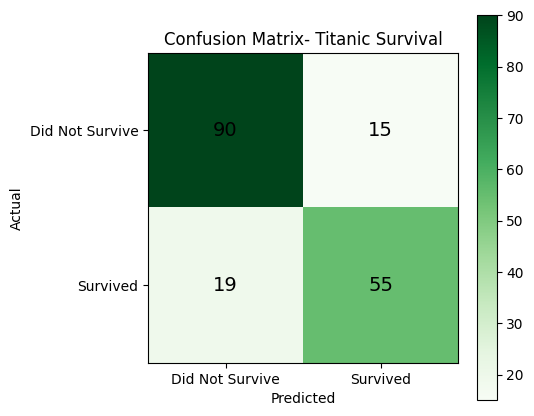

In [ ]:
import matplotlib.pyplot as plt

cm=confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 5))
plt.imshow(cm, cmap='Greens')
plt.title('Confusion Matrix- Titanic Survival')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.yticks([0, 1], ['Did Not Survive', 'Survived'])
for i in range(2):
  for j in range(2):
    plt.text(j, i, cm[i, j], ha='center', va='center', fontsize=14, color='black')
plt.colorbar()
plt.show()


In [ ]:
sample = x_test.iloc[[0]]
prediction = model.predict(sample)[0]
probability = model.predict_proba(sample)[0][1]

print("Predicted:", "Survived" if prediction == 1 else "Did Not Survive")
print("Probability of Survival:", round(probability, 2))

Predicted: Did Not Survive
Probability of Survival: 0.11
